<a href="https://colab.research.google.com/github/Parthwadekar40/Parth40-MachineVision/blob/main/Prac5_MV_Parth40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== ATTENDANCE DETECTOR EVALUATION REPORT ===
Condition: Low Light (Dark)     | Detected Faces: 1 | Detected Eyes: 1
Condition: Normal Light         | Detected Faces: 1 | Detected Eyes: 2
Condition: Overexposed (Bright) | Detected Faces: 1 | Detected Eyes: 2


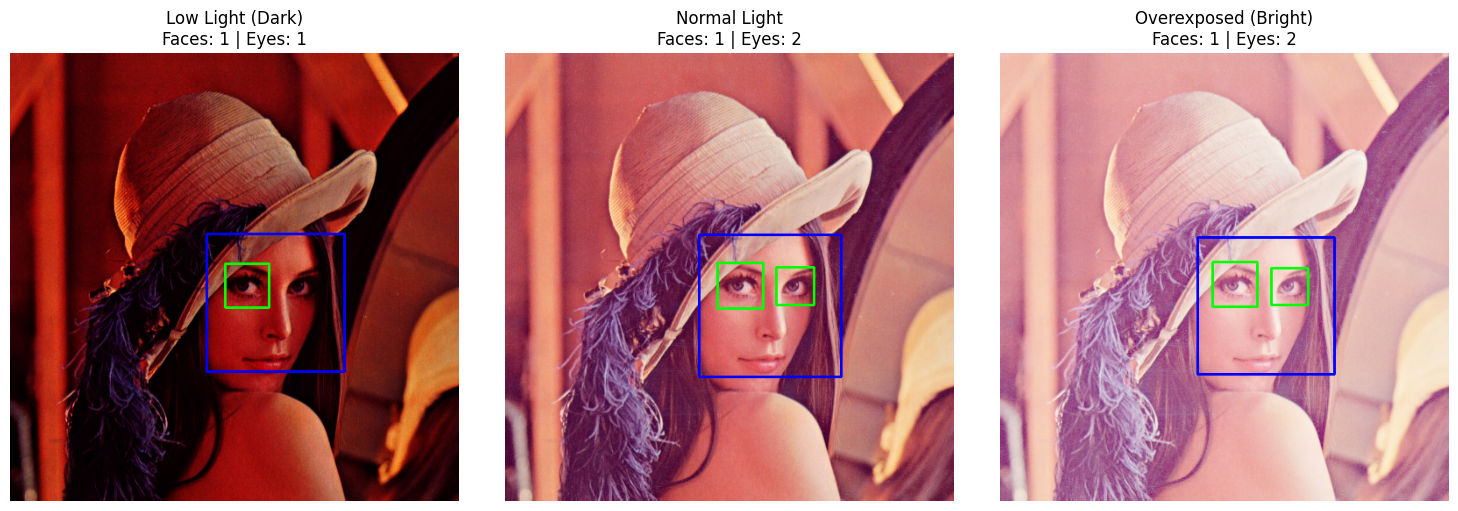

In [7]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

# --- STEP 1: Download Haar Cascade Pre-trained Models ---
face_cascade_url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
eye_cascade_url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_eye.xml"

urllib.request.urlretrieve(face_cascade_url, "haarcascade_frontalface_default.xml")
urllib.request.urlretrieve(eye_cascade_url, "haarcascade_eye.xml")

face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier("haarcascade_eye.xml")


# --- STEP 2: Detection Function ---
def detect_face_and_eyes(image):
    """
    Detects faces and eyes within face regions, returning the annotated image and detection counts.
    """
    img_out = image.copy()
    gray = cv2.cvtColor(img_out, cv2.COLOR_BGR2GRAY)

    # Fine-tuned scale factor and minNeighbors
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5, minSize=(30, 30))

    total_faces = len(faces)
    total_eyes = 0

    for (x, y, w, h) in faces:
        # Draw bounding box for face (Blue)
        cv2.rectangle(img_out, (x, y), (x + w, y + h), (255, 0, 0), 2)

        # Region of Interest (ROI) for Eyes inside the face
        roi_gray = gray[y:y + h, x:x + w]
        roi_color = img_out[y:y + h, x:x + w]

        eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=10, minSize=(15, 15))
        total_eyes += len(eyes)

        for (ex, ey, ew, eh) in eyes:
            # Draw bounding box for eyes (Green)
            cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

    return img_out, total_faces, total_eyes


# --- STEP 3: Lighting Simulation Helper ---
def adjust_lighting(image, gamma=1.0):
    """
    Adjusts brightness using gamma correction.
    gamma < 1.0 -> Low Light
    gamma > 1.0 -> Overexposed/High Light
    """
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(image, table)


# --- STEP 4: Run Evaluation with Sample Synthetic/Loaded Image ---
# Creating a basic synthetic test face image if local file isn't uploaded
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
urllib.request.urlretrieve(url, "test_student.jpg")

base_img = cv2.imread("test_student.jpg")

# Simulate 3 Lighting Conditions
conditions = {
    "Low Light (Dark)": adjust_lighting(base_img, gamma=0.3),
    "Normal Light": base_img,
    "Overexposed (Bright)": adjust_lighting(base_img, gamma=2.2)
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

print("=== ATTENDANCE DETECTOR EVALUATION REPORT ===")
for idx, (label, img) in enumerate(conditions.items()):
    annotated_img, face_count, eye_count = detect_face_and_eyes(img)

    # Display in RGB format for Matplotlib
    axes[idx].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f"{label}\nFaces: {face_count} | Eyes: {eye_count}")
    axes[idx].axis("off")

    print(f"Condition: {label:<20} | Detected Faces: {face_count} | Detected Eyes: {eye_count}")

plt.tight_layout()
plt.show()

Click below to upload image(s) from your computer:


Saving close-up-portrait-smiling-young-woman-looking-camera_171337-17994.avif to close-up-portrait-smiling-young-woman-looking-camera_171337-17994.avif


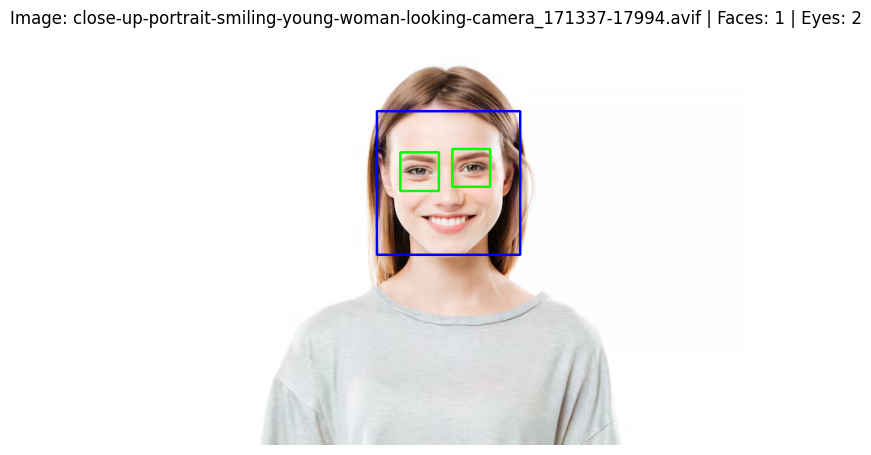

File: close-up-portrait-smiling-young-woman-looking-camera_171337-17994.avif -> Detected 1 face(s) and 2 eye(s).


In [11]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# 1. Upload your image file(s)
print("Click below to upload image(s) from your computer:")
uploaded = files.upload()

# 2. Process each uploaded image
for filename in uploaded.keys():
    # Read image
    img = cv2.imread(filename)

    # Run through the detection function defined earlier
    annotated_img, face_count, eye_count = detect_face_and_eyes(img)

    # Plot results
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Image: {filename} | Faces: {face_count} | Eyes: {eye_count}")
    plt.axis('off')
    plt.show()

    print(f"File: {filename} -> Detected {face_count} face(s) and {eye_count} eye(s).")

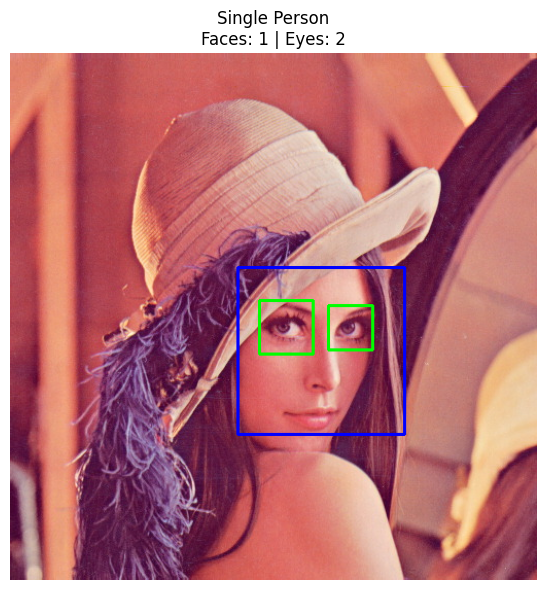

In [19]:
import urllib.request
import cv2
import matplotlib.pyplot as plt

# Public face image URLs for testing
sample_urls = {
    "Single Person": "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
    # Removed 'Classroom Group' due to persistent HTTP download issues.
    # Please use the 'Upload your own images for detection' cell (8v9grgAcLBTJ) to test with group photos.
}

# Create subplots only if there's more than one sample, otherwise adjust for single plot.
# If we always have 'Single Person', it's 1 image, so 1 subplot is enough.
fig, axes = plt.subplots(1, len(sample_urls), figsize=(7 * len(sample_urls), 6))

# Ensure axes is iterable even if it's a single Axes object
if not isinstance(axes, (np.ndarray, list)):
    axes = [axes]

for idx, (label, url) in enumerate(sample_urls.items()):
    # Download sample image
    img_name = f"sample_{idx}.jpg"
    try:
        urllib.request.urlretrieve(url, img_name)
    except Exception as e:
        print(f"Error downloading {label} image from {url}: {e}")
        continue

    # Read and detect
    img = cv2.imread(img_name)
    if img is None:
        print(f"Error: Could not load image from {img_name} (downloaded from {url}). It might be corrupted or not a valid image format.")
        continue

    annotated_img, faces, eyes = detect_face_and_eyes(img)

    # Display results
    axes[idx].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f"{label}\nFaces: {faces} | Eyes: {eyes}")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()